In [1]:
import sys
import os
from os.path import join
import glob
from copy import deepcopy

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display, clear_output
from tqdm import tqdm

sys.path.insert(0, "../../ABC-SN/code")
import abcsn_config
import abcsn_training
import data_degrading as dg
import data_plotting as dplt
import data_preparation as dp
import preprocessing

sys.path.insert(0, "../code")
import review_spectrum as rs
import spectral_features as sf
import measure_signal as ms

from icecream import ic
from importlib import reload

2026-03-14 17:49:15.446539: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
REPO_DIR = "../"
DATA_DIR = join(REPO_DIR, "data")

In [3]:
file_SNRmetadata = join(DATA_DIR, "forSNR", "SNRmetadata_nodupe.parquet")
file_data = join(DATA_DIR, "forSNR", "data_nodupe.parquet")
file_meta = join(DATA_DIR, "forSNR", "metadata_nodupe.parquet")
file_data_full = join(DATA_DIR, "forSNR", "data.parquet")
file_meta_full = join(DATA_DIR, "forSNR", "metadata.parquet")


df_SNRmetadata = pd.read_parquet(file_SNRmetadata)
df_data = pd.read_parquet(file_data)
df_meta = pd.read_parquet(file_meta)
df_data_full = pd.read_parquet(file_data_full)
df_meta_full = pd.read_parquet(file_meta_full)

In [4]:
df_SNRmetadata.shape, df_data.shape, df_meta.shape

((3625, 16), (3625, 1024), (3625, 6))

In [5]:
df_data_full.shape, df_meta_full.shape

((3764, 1024), (3764, 6))

In [6]:
wvl = df_data.columns.to_numpy().astype(float)

In [7]:
df_meta_full.shape

(3764, 6)

In [8]:
df_SNRmetadata["Denoising Parameter"].value_counts(dropna=False)

Denoising Parameter
 10.0     2251
 20.0      733
 15.0      328
-999.0     159
 30.0      151
 25.0        2
 50.0        1
Name: count, dtype: int64

# 1. Get a list of all of the spectra that were removed from the dataset

One supernova was removed in its entirety.

If a spectrum was found to have the same name and phase as another spectrum, both were removed from from dataset. Tihs is what constitutes the difference between `file_meta`/`file_data` and `file_meta_full`/`file_data_full`.

We are going to find these and re-add them, then check if they were actually duplicate spectra or just had duplicate names.

In [9]:
removed_inds = []
for i in range(df_meta_full.shape[0]):
    row_series = df_meta_full.loc[i].copy(deep=True)
    sn_name = row_series["SN Name"]
    sn_subtype = row_series["SN Subtype"]
    sn_phase = row_series["Spectral Phase"]

    mask = df_SNRmetadata["SN Name"] == sn_name
    mask &= df_SNRmetadata["Spectral Phase"] == sn_phase
    num_spec_shared = mask.sum()
    assert num_spec_shared <= 1

    if num_spec_shared == 0:
        removed_inds.append(i)

In [10]:
for i in removed_inds:
    row_series = df_meta_full.loc[i].copy(deep=True)
    sn_name = row_series["SN Name"]
    sn_subtype = row_series["SN Subtype"]
    sn_phase = row_series["Spectral Phase"]
    print(i, sn_name, sn_subtype, sn_phase)

112 sn94D Ia-norm 15.2
117 sn94D Ia-norm 15.2
141 sn2001ep Ia-norm 2.8
142 sn2001ep Ia-norm 2.8
205 sn2001ay Ia-norm 3.3
206 sn2001ay Ia-norm 3.3
218 sn2001ay Ia-norm 31.4
219 sn2001ay Ia-norm 31.4
347 sn2004dt Ia-norm -6.5
348 sn2004dt Ia-norm -6.5
420 sn2002bo Ia-norm -1.5
421 sn2002bo Ia-norm -1.5
595 sn2003cg Ia-norm -2.1
596 sn2003cg Ia-norm -2.1
617 sn2003cg Ia-norm 22.9
618 sn2003cg Ia-norm 22.9
886 sn2002dj Ia-norm -11.4
887 sn2002dj Ia-norm -11.4
888 sn2002dj Ia-norm -10.4
889 sn2002dj Ia-norm -10.4
1048 sn1994D Ia-norm 49.5
1049 sn1994D Ia-norm 49.5
1152 sn1995al Ia-norm 16.4
1153 sn1995al Ia-norm 16.4
1249 sn2003ch Ia-norm 1.8
1250 sn2003ch Ia-norm 1.8
1268 sn2002kf Ia-norm 29.5
1269 sn2002kf Ia-norm 29.5
1346 sn94ae Ia-norm 3.3
1347 sn94ae Ia-norm 3.3
1498 sn2002ap Ic-broad 30.5
1499 sn2002ap Ic-broad 30.5
1505 sn2000fa Ia-norm -10.4
1506 sn2000fa Ia-norm -10.4
1626 sn1996X Ia-norm 7.1
1627 sn1996X Ia-norm 7.1
1751 sn2007qe Ia-norm 18.7
1752 sn2007qe Ia-norm 18.7
1757 sn200

# 2. Now look through every single pair of spectra and compare them to see if any are truly duplicates.

In [11]:
num_spec = df_meta_full.shape[0]
pair_indices = np.triu_indices(num_spec, k=1)

congruent_spectra = []
for (i, j) in tqdm(zip(*pair_indices)):
    spectrum_i = df_data_full.loc[i].to_numpy()
    spectrum_j = df_data_full.loc[j].to_numpy()

    if np.array_equal(spectrum_i, spectrum_j):
        name_i = df_meta_full["SN Name"].loc[i]
        name_j = df_meta_full["SN Name"].loc[j]
        subtype_i = df_meta_full["SN Subtype"].loc[i]
        subtype_j = df_meta_full["SN Subtype"].loc[j]
        phase_i = df_meta_full["Spectral Phase"].loc[i]
        phase_j = df_meta_full["Spectral Phase"].loc[j]
    
        info_i = (i, name_i, subtype_i, phase_i)
        info_j = (j, name_j, subtype_j, phase_j)
        congruent_spectra.append((info_i, info_j))

7081966it [12:39, 9329.89it/s] 


In [12]:
congruent_spectra

[((3139, 'LSQ14efd', 'Ic-norm', 31.93), (3140, 'LSQ14efd', 'Ic-norm', 31.93)),
 ((3553, 'sn2004fe', 'Ic-norm', -6.78), (3554, 'sn2004fe', 'Ic-norm', -6.78))]

# 3. We have our list of pairs of spectra that are identical. We need to remove one copy of them. Doesn't matter which.

It turns out that the two pairs of spectra that are identical also happened to have the same sn_name and phase. We have our list of `removed_inds`, spectra that were removed from the dataset. And now we know that there are two pairs in that list that are truly duplicates of one another. `mask` is a boolean index for `removed_inds` that can remove those to pairs.

Next we can generate this list `wrongfully_removed_inds` of spectra that we want to add back to the dataset. 

In [13]:
mask = np.zeros_like(removed_inds).astype(bool)
for spectra_pair in congruent_spectra:
    i = spectra_pair[0][0]
    j = spectra_pair[1][0]
    name_i = spectra_pair[0][1]
    name_j = spectra_pair[1][1]
    subtype_i = spectra_pair[0][2]
    subtype_j = spectra_pair[1][2]
    phase_i = spectra_pair[0][3]
    phase_j = spectra_pair[1][3]
    
    mask |= removed_inds == i

In [14]:
wrongfully_removed_inds = np.array(removed_inds)[~mask]
wrongfully_removed_inds

array([ 112,  117,  141,  142,  205,  206,  218,  219,  347,  348,  420,
        421,  595,  596,  617,  618,  886,  887,  888,  889, 1048, 1049,
       1152, 1153, 1249, 1250, 1268, 1269, 1346, 1347, 1498, 1499, 1505,
       1506, 1626, 1627, 1751, 1752, 1757, 1758, 1792, 1793, 1983, 1984,
       2011, 2012, 2029, 2030, 2137, 2138, 2318, 2319, 2320, 2321, 2322,
       2323, 2324, 2328, 2329, 2378, 2379, 2575, 2576, 2889, 2890, 3004,
       3005, 3011, 3012, 3015, 3016, 3017, 3023, 3024, 3045, 3046, 3047,
       3048, 3049, 3050, 3051, 3052, 3053, 3054, 3055, 3056, 3057, 3058,
       3059, 3060, 3061, 3062, 3084, 3085, 3086, 3087, 3088, 3089, 3090,
       3091, 3092, 3140, 3187, 3188, 3191, 3192, 3196, 3197, 3198, 3199,
       3213, 3214, 3486, 3487, 3523, 3524, 3541, 3542, 3547, 3548, 3554,
       3583, 3584, 3593, 3594, 3595, 3596, 3631, 3632, 3690, 3691, 3695,
       3696, 3698, 3699, 3762, 3763])

# 4. We found only two cases where a spectrum was completely duplicated not just in name but in data.

`df_meta_corrected`, `df_data_corrected` and `df_SNRmetadata_corrected` have had all the other spectra re-added to the dataset except for those two.

`df_all` is now a dataframe containing the data, metadata, and SNR info all at once.

In [15]:
for i in wrongfully_removed_inds:
    row_series = df_meta_full.loc[i].copy(deep=True)
    sn_name = row_series["SN Name"]
    sn_subtype = row_series["SN Subtype"]
    sn_phase = row_series["Spectral Phase"]
    print(i, sn_name, sn_subtype, sn_phase)

112 sn94D Ia-norm 15.2
117 sn94D Ia-norm 15.2
141 sn2001ep Ia-norm 2.8
142 sn2001ep Ia-norm 2.8
205 sn2001ay Ia-norm 3.3
206 sn2001ay Ia-norm 3.3
218 sn2001ay Ia-norm 31.4
219 sn2001ay Ia-norm 31.4
347 sn2004dt Ia-norm -6.5
348 sn2004dt Ia-norm -6.5
420 sn2002bo Ia-norm -1.5
421 sn2002bo Ia-norm -1.5
595 sn2003cg Ia-norm -2.1
596 sn2003cg Ia-norm -2.1
617 sn2003cg Ia-norm 22.9
618 sn2003cg Ia-norm 22.9
886 sn2002dj Ia-norm -11.4
887 sn2002dj Ia-norm -11.4
888 sn2002dj Ia-norm -10.4
889 sn2002dj Ia-norm -10.4
1048 sn1994D Ia-norm 49.5
1049 sn1994D Ia-norm 49.5
1152 sn1995al Ia-norm 16.4
1153 sn1995al Ia-norm 16.4
1249 sn2003ch Ia-norm 1.8
1250 sn2003ch Ia-norm 1.8
1268 sn2002kf Ia-norm 29.5
1269 sn2002kf Ia-norm 29.5
1346 sn94ae Ia-norm 3.3
1347 sn94ae Ia-norm 3.3
1498 sn2002ap Ic-broad 30.5
1499 sn2002ap Ic-broad 30.5
1505 sn2000fa Ia-norm -10.4
1506 sn2000fa Ia-norm -10.4
1626 sn1996X Ia-norm 7.1
1627 sn1996X Ia-norm 7.1
1751 sn2007qe Ia-norm 18.7
1752 sn2007qe Ia-norm 18.7
1757 sn200

In [28]:
len(wrongfully_removed_inds)

137

In [16]:
df_meta.shape

(3625, 6)

In [17]:
df_meta_corrected = pd.concat([df_meta, df_meta_full.loc[wrongfully_removed_inds].copy(deep=True)])
df_data_corrected = pd.concat([df_data, df_data_full.loc[wrongfully_removed_inds].copy(deep=True)])

In [18]:
df_SNRmetadata_corrected = pd.concat([df_SNRmetadata, df_meta_full.loc[wrongfully_removed_inds].copy(deep=True)])
df_SNRmetadata_corrected

,SN Name,SN Subtype,SN Subtype ID,SN Maintype,SN Maintype ID,Spectral Phase,Denoising Parameter,minima_i,searchBlu,searchRed,useBlu,useRed,maxBlu,maxRed,noiseWindowBlu,noiseWindowRed
0,sn2008ar,Ia-norm,0,Ia,0,-8.5,15.0,NaN,500.0,0.0,True,True,0.0,0.0,100.0,100.0
1,sn2008ar,Ia-norm,0,Ia,0,-7.5,10.0,NaN,500.0,0.0,True,True,0.0,0.0,100.0,100.0
2,sn2008ar,Ia-norm,0,Ia,0,-6.6,20.0,NaN,500.0,0.0,True,True,0.0,0.0,100.0,100.0
3,sn2008ar,Ia-norm,0,Ia,0,-4.6,15.0,NaN,500.0,0.0,True,True,0.0,0.0,100.0,100.0
4,sn2008ar,Ia-norm,0,Ia,0,-3.7,15.0,NaN,500.0,0.0,True,True,0.0,0.0,100.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3696,sn2013dx,Ic-broad,8,Ic,2,1.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3698,sn2013dx,Ic-broad,8,Ic,2,4.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3699,sn2013dx,Ic-broad,8,Ic,2,4.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3762,sn2003jd,Ic-broad,8,Ic,2,49.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df_all = pd.concat([df_SNRmetadata_corrected, df_data_corrected], axis=1)

In [20]:
df_all

,SN Name,SN Subtype,SN Subtype ID,SN Maintype,SN Maintype ID,Spectral Phase,Denoising Parameter,minima_i,searchBlu,searchRed,...,9872.21,9885.59,9898.98,9912.39,9925.82,9939.27,9952.73,9966.21,9979.71,9993.24
0,sn2008ar,Ia-norm,0,Ia,0,-8.5,15.0,NaN,500.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,sn2008ar,Ia-norm,0,Ia,0,-7.5,10.0,NaN,500.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,sn2008ar,Ia-norm,0,Ia,0,-6.6,20.0,NaN,500.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,sn2008ar,Ia-norm,0,Ia,0,-4.6,15.0,NaN,500.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,sn2008ar,Ia-norm,0,Ia,0,-3.7,15.0,NaN,500.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3696,sn2013dx,Ic-broad,8,Ic,2,1.3,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3698,sn2013dx,Ic-broad,8,Ic,2,4.6,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3699,sn2013dx,Ic-broad,8,Ic,2,4.6,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3762,sn2003jd,Ic-broad,8,Ic,2,49.4,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 5. Now we need to handle the naming convention of the supernova.

The following code takes the "SN Name" columns and splits it up into 3 components: the prefix, the year and the suffix. For example, we can now associate `sn98aa` and `sn1998aa` as the same supernova because they have the same year (1998) and suffix (aa). This was a possible source of dataset contamination.

In [21]:
def expand_sn_name(sn_name):
    obs_prefix = None
    obs_year = None
    obs_suffix = None

    if sn_name.startswith("sn"):
        obs_prefix = "sn"
        sn_name = sn_name.strip(obs_prefix)

    elif sn_name.startswith("PTF"):
        obs_prefix = "PTF"
        sn_name = sn_name.strip(obs_prefix)

    elif sn_name.startswith("iPTF"):
        obs_prefix = "iPTF"
        sn_name = sn_name.strip(obs_prefix)

    elif sn_name.startswith("LSQ"):
        obs_prefix = "LSQ"
        sn_name = sn_name.strip(obs_prefix)

    elif sn_name[0].isdigit():
        obs_prefix = "unknown"

    else:
        assert False, sn_name


    digits = []
    for char in sn_name:
        digits.append(char.isdigit())
    char_inds = np.where(digits)[0]
    obs_year = sn_name[:char_inds[-1]+1]

    if len(obs_year) == 4:
        obs_suffix = sn_name[4:]
        obs_year == int(obs_year)
        
    elif len(obs_year) == 2:
        obs_suffix = sn_name[2:]
        if obs_year[0] in ["0", "1", "2"]:
            obs_year = f"20{obs_year}"
        else:
            obs_year = f"19{obs_year}"

    return obs_prefix, int(obs_year), obs_suffix
        

print(expand_sn_name("sn2008ar"))
print(expand_sn_name("sn05eq"))
print(expand_sn_name("17ein"))
print(expand_sn_name("PTF10vgv"))
print(expand_sn_name("LSQ14efd"))
print(expand_sn_name("iPTF13bvn"))
print(expand_sn_name("sn94ae"))

('sn', 2008, 'ar')
('sn', 2005, 'eq')
('unknown', 2017, 'ein')
('PTF', 2010, 'vgv')
('LSQ', 2014, 'efd')
('iPTF', 2013, 'bvn')
('sn', 1994, 'ae')


In [22]:
def fn(x):
    obs_prefix, obs_year, obs_suffix = expand_sn_name(x["SN Name"])
    
    x["name_prefix"] = obs_prefix
    x["name_year"] = obs_year
    x["name_suffix"] = obs_suffix
    return x

df_all_renamed = df_all.apply(fn, axis=1)
df_all_renamed = df_all_renamed.loc[:, [*df_all_renamed.columns[-3:], *df_all_renamed.columns[:-3]]].copy(deep=True)
df_all_renamed

,name_prefix,name_year,name_suffix,SN Name,SN Subtype,SN Subtype ID,SN Maintype,SN Maintype ID,Spectral Phase,Denoising Parameter,...,9872.21,9885.59,9898.98,9912.39,9925.82,9939.27,9952.73,9966.21,9979.71,9993.24
0,sn,2008,ar,sn2008ar,Ia-norm,0,Ia,0,-8.5,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,sn,2008,ar,sn2008ar,Ia-norm,0,Ia,0,-7.5,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,sn,2008,ar,sn2008ar,Ia-norm,0,Ia,0,-6.6,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,sn,2008,ar,sn2008ar,Ia-norm,0,Ia,0,-4.6,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,sn,2008,ar,sn2008ar,Ia-norm,0,Ia,0,-3.7,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3696,sn,2013,dx,sn2013dx,Ic-broad,8,Ic,2,1.3,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3698,sn,2013,dx,sn2013dx,Ic-broad,8,Ic,2,4.6,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3699,sn,2013,dx,sn2013dx,Ic-broad,8,Ic,2,4.6,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3762,sn,2003,jd,sn2003jd,Ic-broad,8,Ic,2,49.4,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
df = df_all_renamed.sort_values(["SN Subtype ID", "name_year", "name_suffix", "Spectral Phase"]).copy(deep=True)
df

,name_prefix,name_year,name_suffix,SN Name,SN Subtype,SN Subtype ID,SN Maintype,SN Maintype ID,Spectral Phase,Denoising Parameter,...,9872.21,9885.59,9898.98,9912.39,9925.82,9939.27,9952.73,9966.21,9979.71,9993.24
984,sn,1981,B,sn1981B,Ia-norm,0,Ia,0,-1.5,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
985,sn,1981,B,sn1981B,Ia-norm,0,Ia,0,15.4,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
986,sn,1981,B,sn1981B,Ia-norm,0,Ia,0,18.3,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
987,sn,1981,B,sn1981B,Ia-norm,0,Ia,0,22.3,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
988,sn,1981,B,sn1981B,Ia-norm,0,Ia,0,26.3,-999.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,sn,2006,bp,sn2006bp,IIP,9,II,3,17.2,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
904,sn,2006,bp,sn2006bp,IIP,9,II,3,20.1,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
905,sn,2006,bp,sn2006bp,IIP,9,II,3,25.2,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
906,sn,2006,bp,sn2006bp,IIP,9,II,3,34.1,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
df["Denoising Parameter"].value_counts(dropna=False)

Denoising Parameter
 10.0     2251
 20.0      733
 15.0      328
-999.0     159
 30.0      151
 NaN       137
 25.0        2
 50.0        1
Name: count, dtype: int64

In [35]:
df["Spectrum Cardinality"] = 1

In [58]:
def fn1(x):
    if x.shape[0] == 1:
        return x

    for k, i in enumerate(x.index[1:]):
        x.loc[i, "Spectrum Cardinality"] += k + 1

    # print(x[["name_year", "name_suffix", "Spectral Phase", "Spectrum Cardinality"]])

    return x


df_a = df.groupby(by=["name_year", "name_suffix", "Spectral Phase"]).apply(fn1)
df_a.reset_index(drop=True, inplace=True)

/var/folders/4f/d1ds3nbj355830gn3smjnr900000gn/T/ipykernel_23930/1084527834.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_a = df.groupby(by=["name_year", "name_suffix", "Spectral Phase"]).apply(fn1)


In [62]:
df_a

,name_prefix,name_year,name_suffix,SN Name,SN Subtype,SN Subtype ID,SN Maintype,SN Maintype ID,Spectral Phase,Denoising Parameter,...,9885.59,9898.98,9912.39,9925.82,9939.27,9952.73,9966.21,9979.71,9993.24,Spectrum Cardinality
0,sn,1981,B,sn1981B,Ia-norm,0,Ia,0,-1.50,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,sn,1981,B,sn1981B,Ia-norm,0,Ia,0,15.40,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,sn,1981,B,sn1981B,Ia-norm,0,Ia,0,18.30,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,sn,1981,B,sn1981B,Ia-norm,0,Ia,0,22.30,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,sn,1981,B,sn1981B,Ia-norm,0,Ia,0,26.30,-999.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3757,unknown,2017,ein,17ein,Ic-norm,7,Ic,2,15.22,-999.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3758,unknown,2017,ein,17ein,Ic-norm,7,Ic,2,18.29,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3759,unknown,2017,ein,17ein,Ic-norm,7,Ic,2,22.27,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3760,unknown,2017,ein,17ein,Ic-norm,7,Ic,2,38.24,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [66]:
df_b = df_a[[*df_a.columns[:9], df_a.columns[-1], *df_a.columns[9:-1]]].copy(deep=True)

In [70]:
for i in df_b.columns.to_numpy():
    print(i)

name_prefix
name_year
name_suffix
SN Name
SN Subtype
SN Subtype ID
SN Maintype
SN Maintype ID
Spectral Phase
Spectrum Cardinality
Denoising Parameter
minima_i
searchBlu
searchRed
useBlu
useRed
maxBlu
maxRed
noiseWindowBlu
noiseWindowRed
2501.69
2505.08
2508.48
2511.87
2515.28
2518.69
2522.1
2525.51
2528.94
2532.36
2535.79
2539.23
2542.67
2546.11
2549.56
2553.01
2556.47
2559.94
2563.4
2566.88
2570.35
2573.84
2577.32
2580.82
2584.31
2587.81
2591.32
2594.83
2598.34
2601.86
2605.39
2608.92
2612.45
2615.99
2619.54
2623.08
2626.64
2630.2
2633.76
2637.33
2640.9
2644.48
2648.06
2651.65
2655.24
2658.84
2662.44
2666.05
2669.66
2673.27
2676.9
2680.52
2684.15
2687.79
2691.43
2695.08
2698.73
2702.38
2706.05
2709.71
2713.38
2717.06
2720.74
2724.43
2728.12
2731.81
2735.51
2739.22
2742.93
2746.65
2750.37
2754.09
2757.82
2761.56
2765.3
2769.05
2772.8
2776.55
2780.32
2784.08
2787.85
2791.63
2795.41
2799.2
2802.99
2806.79
2810.59
2814.4
2818.21
2822.03
2825.85
2829.68
2833.51
2837.35
2841.2
2845.05
2848.

In [72]:
df_b["Denoising Parameter"].value_counts(dropna=False)

Denoising Parameter
 10.0     2251
 20.0      733
 15.0      328
-999.0     159
 30.0      151
 NaN       137
 25.0        2
 50.0        1
Name: count, dtype: int64

In [73]:
df_b.to_parquet(join(DATA_DIR, "forSNR", "data_metadata_SNRinfo.parquet"))

In [77]:
dataset = df_b

In [79]:
df_fluxes = dataset.filter(regex="\d+").copy(deep=True)
wvl = df_fluxes.columns.to_numpy(dtype=float)

In [80]:
df_fluxes

,2501.69,2505.08,2508.48,2511.87,2515.28,2518.69,2522.1,2525.51,2528.94,2532.36,...,9872.21,9885.59,9898.98,9912.39,9925.82,9939.27,9952.73,9966.21,9979.71,9993.24
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3757,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3758,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3759,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3760,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [81]:
wvl

array([2501.69, 2505.08, 2508.48, ..., 9966.21, 9979.71, 9993.24])

In [82]:
df_meta

,Denoising Parameter,SN Maintype,SN Maintype ID,SN Name,SN Subtype,SN Subtype ID,Spectral Phase,Spectrum Cardinality,maxBlu,maxRed,minima_i,name_prefix,name_suffix,name_year,noiseWindowBlu,noiseWindowRed,searchBlu,searchRed,useBlu,useRed
0,10.0,Ia,0,sn1981B,Ia-norm,0,-1.50,1,0.0,0.0,NaN,sn,B,1981,100.0,100.0,500.0,0.0,True,True
1,10.0,Ia,0,sn1981B,Ia-norm,0,15.40,1,0.0,0.0,NaN,sn,B,1981,100.0,100.0,500.0,0.0,True,True
2,10.0,Ia,0,sn1981B,Ia-norm,0,18.30,1,0.0,0.0,NaN,sn,B,1981,100.0,100.0,500.0,0.0,True,True
3,10.0,Ia,0,sn1981B,Ia-norm,0,22.30,1,0.0,0.0,NaN,sn,B,1981,100.0,100.0,500.0,0.0,True,True
4,-999.0,Ia,0,sn1981B,Ia-norm,0,26.30,1,0.0,1.0,NaN,sn,B,1981,100.0,100.0,500.0,0.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3757,-999.0,Ic,2,17ein,Ic-norm,7,15.22,1,0.0,0.0,NaN,unknown,ein,2017,100.0,100.0,500.0,0.0,True,True
3758,10.0,Ic,2,17ein,Ic-norm,7,18.29,1,0.0,0.0,NaN,unknown,ein,2017,100.0,100.0,500.0,0.0,True,True
3759,10.0,Ic,2,17ein,Ic-norm,7,22.27,1,0.0,0.0,NaN,unknown,ein,2017,100.0,100.0,500.0,0.0,True,True
3760,10.0,Ic,2,17ein,Ic-norm,7,38.24,1,0.0,0.0,NaN,unknown,ein,2017,100.0,100.0,500.0,0.0,True,True


In [76]:
join(DATA_DIR, "forSNR", "data_metadata_SNRinfo.parquet")

'../data/forSNR/data_metadata_SNRinfo.parquet'

In [91]:
potential_dupes = dataset[dataset["Spectrum Cardinality"] == 2].index.to_numpy()
potential_dupes

array([ 178,  181,  302,  323,  326,  333,  341,  345,  367,  399,  409,
        470,  496, 1230, 1302, 1315, 1405, 1475, 1513, 1612, 1614, 1796,
       1843, 1865, 1875, 1903, 1938, 2024, 2127, 2268, 2376, 2406, 2436,
       2455, 2540, 2542, 2544, 2551, 3274, 3387, 3462, 3472, 3474, 3491,
       3497, 3505, 3508, 3510, 3512, 3588, 3592, 3600, 3645, 3656, 3663,
       3668, 3671, 3699])

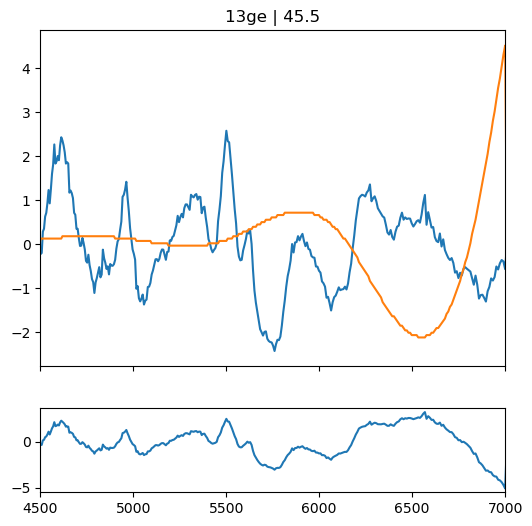

In [105]:
df_fluxes = dataset.filter(regex="\d+").copy(deep=True)

for i in potential_dupes:
    spec1 = df_fluxes.iloc[i-1]
    spec2 = df_fluxes.iloc[i]

    row1 = dataset.iloc[i-1]
    row2 = dataset.iloc[i]

    assert row1["Spectrum Cardinality"] == 1
    assert row2["Spectrum Cardinality"] == 2
    
    assert row1["Spectral Phase"] == row2["Spectral Phase"]
    
    assert row1["SN Name"] == row2["SN Name"]
    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        height_ratios=(4, 1),
        sharex=True,
        figsize=(6, 6)
    )
    axes[0].set_title(f"{row1['SN Name']} | {row1['Spectral Phase']}")
    axes[0].plot(wvl, spec1)
    axes[0].plot(wvl, spec2)
    axes[1].plot(wvl, spec1 - spec2)
    axes[0].set_xlim((4500, 7000))
    fig.show()
    display(plt.gcf())
    input()
    clear_output(wait=True)
    plt.close()